In [1]:
# This is for calculating change in M1, M2 and M3

import numpy as np
import pandas as pd
import xarray as xr
from patsy import cr
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import cftime

# =====================================================================
# STEP 1: LOAD AND PROCESS HISTORICAL DATA (1981-2010)
# =====================================================================

print("="*60)
print("STEP 1: Loading historical climate data (1981-2010)")
print("="*60)

# Load historical CMIP6 data
ds_E_hist = xr.open_dataset('/Users/dianindrawati/Documents/CMIP6_datasets/CMCC-ESM2/hfls/CMCC-ESM2_hfls_present_19812010_annual.nc')
ds_SM_hist = xr.open_dataset('/Users/dianindrawati/Documents/CMIP6_datasets/CMCC-ESM2/mrsos/CMCC-ESM2_mrsos_present_19812010_annual.nc')

# Check if time is cftime and convert
def convert_cftime_to_datetime(ds):
    """Convert cftime to standard datetime64[ns]"""
    if isinstance(ds.time.values[0], cftime.datetime):
        # Convert cftime to pandas datetime
        times = ds.time.values
        new_times = [pd.Timestamp(f"{t.year:04d}-{t.month:02d}-{t.day:02d}") 
                     for t in times]
        ds = ds.assign_coords(time=new_times)
    return ds
    
ds_E_hist = convert_cftime_to_datetime(ds_E_hist)
ds_SM_hist = convert_cftime_to_datetime(ds_SM_hist)

# Select time period and variables
E_hist = ds_E_hist['hfls'].sel(time=slice('1981', '2010'))
SM_hist = ds_SM_hist['mrsos'].sel(time=slice('1981', '2010'))

# Unit conversions
E_hist = E_hist * 86400 / (2.45 * 1e6)  # W/m² to mm/day
SM_hist = SM_hist / (1000 * 0.1)  # kg/m² to m³/m³ (10cm layer)

# Area weighting
weights_hist = np.cos(np.deg2rad(E_hist.lat))
weights_hist1 = np.cos(np.deg2rad(SM_hist.lat))

# Define regions
lat_bins = [(-60, -35), (-35, -23.5), (-23.5, 23.5), (23.5, 35), (35, 60)]
region_names = ['R01_SM', 'R02_SS', 'R03_Tropics', 'R04_NS', 'R05_NM']

STEP 1: Loading historical climate data (1981-2010)


In [2]:
# Extract monthly data by region
rows_hist = []
for i, (lat_min, lat_max) in enumerate(lat_bins):
    region_name = region_names[i]
    
    mask = (E_hist.lat >= lat_min) & (E_hist.lat < lat_max)
    mask1 = (SM_hist.lat >= lat_min) & (SM_hist.lat < lat_max)
    
    E_region = E_hist.where(mask).weighted(weights_hist).mean(dim=['lat', 'lon'])
    SM_region = SM_hist.where(mask1).weighted(weights_hist1).mean(dim=['lat', 'lon'])
    
    for t in range(len(E_region.time)):
        time_obj = E_region.time.values[t]
        
        if isinstance(time_obj, cftime.datetime):
            year = time_obj.year
            month = time_obj.month
        else:
            time_val = pd.Timestamp(time_obj)
            year = time_val.year
            month = time_val.month
        
        rows_hist.append({
            'region': region_name,
            'year': year,
            'month': month,
            'E': float(E_region.isel(time=t).values),
            'SM': float(SM_region.isel(time=t).values)
        })

df_monthly_hist = pd.DataFrame(rows_hist)
print(f"Historical monthly data shape: {df_monthly_hist.shape}")
print(df_monthly_hist.head())



Historical monthly data shape: (54750, 5)
   region  year  month         E        SM
0  R01_SM  1981      1  2.006643  0.204120
1  R01_SM  1981      1  1.854960  0.197346
2  R01_SM  1981      1  1.740965  0.192268
3  R01_SM  1981      1  1.649438  0.201157
4  R01_SM  1981      1  1.498613  0.200031


In [3]:
# Aggregate to annual
def annual_aggregates(group):
    E = group["E"].values
    SM = group["SM"].values

    mean_E = E.mean()
    mean_SM = SM.mean()
    sd_E = E.std(ddof=1)
    sd_SM = SM.std(ddof=1)

    if E.std() > 0 and SM.std() > 0:
        dep = np.corrcoef(E, SM)[0, 1]
    else:
        dep = 0.0

    return pd.Series({
        'E_mean': mean_E,
        'SM_mean': mean_SM,
        'E_sd': sd_E,
        'SM_sd': sd_SM,
        'dep_ESM': dep,
    })

df_annual_hist = df_monthly_hist.groupby(["region", "year"]).apply(annual_aggregates).reset_index()

print(f"\nHistorical annual data shape: {df_annual_hist.shape}")
print(df_annual_hist.head())


Historical annual data shape: (150, 7)
   region  year    E_mean   SM_mean      E_sd     SM_sd   dep_ESM
0  R01_SM  1981  2.394035  0.239067  0.491691  0.040871  0.655009
1  R01_SM  1982  2.396066  0.231751  0.467106  0.030203  0.720426
2  R01_SM  1983  2.417028  0.237615  0.461432  0.035587  0.645598
3  R01_SM  1984  2.405469  0.233680  0.461506  0.034733  0.718855
4  R01_SM  1985  2.433539  0.240176  0.497626  0.040649  0.717109


/var/folders/hr/1kj5bc1x4d7cb6htf9w7ky3h0000gn/T/ipykernel_13513/3065782939.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_annual_hist = df_monthly_hist.groupby(["region", "year"]).apply(annual_aggregates).reset_index()


In [4]:
# Load yield data and merge
df_yields = pd.read_csv('/Users/dianindrawati/Documents/Food_datasets/World_rev2_maize.csv')

df_annual = df_annual_hist.merge(df_yields, on=['region', 'year'], how='inner')
df_annual['log_yield'] = np.log(df_annual['yield'])

print(f"\nMerged historical data shape: {df_annual.shape}")
print(f"Columns: {df_annual.columns.tolist()}")
print(f"Any NaN in log_yield: {df_annual['log_yield'].isna().sum()}")
print("\nFirst few rows:")
print(df_annual.head())


Merged historical data shape: (4581, 10)
Columns: ['region', 'year', 'E_mean', 'SM_mean', 'E_sd', 'SM_sd', 'dep_ESM', 'Area', 'yield', 'log_yield']
Any NaN in log_yield: 0

First few rows:
   region  year    E_mean   SM_mean      E_sd     SM_sd   dep_ESM  \
0  R01_SM  1981  2.394035  0.239067  0.491691  0.040871  0.655009   
1  R01_SM  1981  2.394035  0.239067  0.491691  0.040871  0.655009   
2  R01_SM  1981  2.394035  0.239067  0.491691  0.040871  0.655009   
3  R01_SM  1981  2.394035  0.239067  0.491691  0.040871  0.655009   
4  R01_SM  1981  2.394035  0.239067  0.491691  0.040871  0.655009   

          Area     yield  log_yield  
0    Argentina  3.800825   1.335218  
1    Australia  3.058407   1.117894  
2        Chile  4.127699   1.417720  
3      Lesotho  0.846665  -0.166450  
4  New Zealand  8.829540   2.178103  


In [5]:
# =====================================================================
# FIT MODELS ON HISTORICAL DATA (without year fixed effects)
# =====================================================================

print("\n" + "="*60)
print("FITTING MODELS ON HISTORICAL DATA")
print("="*60)

# Model formulas (without year fixed effects for future predictions)
formula_m1 = """
log_yield ~ cr(E_mean, df=4) + cr(SM_mean, df=4)
     + C(region)
"""

formula_m2 = """
log_yield ~ cr(E_mean, df=4) + cr(SM_mean, df=4)
     + cr(E_sd, df=4) + cr(SM_sd, df=4)
     + C(region)
"""

formula_m3 = """
log_yield ~ cr(E_mean, df=4) + cr(SM_mean, df=4)
     + cr(E_sd, df=4) + cr(SM_sd, df=4)
     + cr(dep_ESM, df=4)
     + C(region)
"""

# Fit models
m1_no_year = smf.ols(formula_m1, data=df_annual).fit()
m2_no_year = smf.ols(formula_m2, data=df_annual).fit()
m3_no_year = smf.ols(formula_m3, data=df_annual).fit()

# Model comparison
def model_stats(model, name):
    return {
        "model": name,
        "AIC": model.aic,
        "BIC": model.bic,
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj,
    }

summary_df = pd.DataFrame([
    model_stats(m1_no_year, "M1: mean only"),
    model_stats(m2_no_year, "M2: mean + variability"),
    model_stats(m3_no_year, "M3: mean + variability + coupling"),
])

print("\n=== Model comparison ===")
print(summary_df)

print("\n=== ANOVA: Does variability improve fit? ===")
print(anova_lm(m1_no_year, m2_no_year))

print("\n=== ANOVA: Does coupling improve fit? ===")
print(anova_lm(m2_no_year, m3_no_year))


FITTING MODELS ON HISTORICAL DATA

=== Model comparison ===
                               model          AIC          BIC        R2  \
0                      M1: mean only  9501.225468  9571.951866  0.371157   
1             M2: mean + variability  9499.706213  9609.010647  0.373010   
2  M3: mean + variability + coupling  9503.466489  9632.059940  0.373316   

     Adj_R2  
0  0.369781  
1  0.370812  
2  0.370706  

=== ANOVA: Does variability improve fit? ===
   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0    4570.0  2123.972872      0.0       NaN       NaN       NaN
1    4564.0  2117.713933      6.0  6.258939  2.248163  0.036084

=== ANOVA: Does coupling improve fit? ===
   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0    4564.0  2117.713933      0.0       NaN       NaN       NaN
1    4561.0  2116.678802      3.0  1.035131  0.743497  0.526026


In [6]:
# =====================================================================
# STEP 2: LOAD AND PROCESS FUTURE CLIMATE DATA (2071-2100)
# =====================================================================

print("\n" + "="*60)
print("STEP 2: Loading future climate data (2071-2100)")
print("="*60)

# Load future CMIP6 data
ds_E_future = xr.open_dataset('/Users/dianindrawati/Documents/CMIP6_datasets/CMCC-ESM2/hfls/CMCC-ESM2_hfls_future585_20712100_annual.nc')
ds_SM_future = xr.open_dataset('/Users/dianindrawati/Documents/CMIP6_datasets/CMCC-ESM2/mrsos/CMCC-ESM2_mrsos_future585_20712100_annual.nc')

# Check if time is cftime and convert
def convert_cftime_to_datetime(ds):
    """Convert cftime to standard datetime64[ns]"""
    if isinstance(ds.time.values[0], cftime.datetime):
        # Convert cftime to pandas datetime
        times = ds.time.values
        new_times = [pd.Timestamp(f"{t.year:04d}-{t.month:02d}-{t.day:02d}") 
                     for t in times]
        ds = ds.assign_coords(time=new_times)
    return ds
    
ds_E_future = convert_cftime_to_datetime(ds_E_future)
ds_SM_future = convert_cftime_to_datetime(ds_SM_future)

# Select time period
E_future = ds_E_future['hfls'].sel(time=slice('2071', '2100'))
SM_future = ds_SM_future['mrsos'].sel(time=slice('2071', '2100'))

# Unit conversions (same as historical)
E_future = E_future * 86400 / (2.45 * 1e6)  # W/m² to mm/day
SM_future = SM_future / (1000 * 0.1)  # kg/m² to m³/m³

# Area weighting
weights_future = np.cos(np.deg2rad(E_future.lat))
weights_future1 = np.cos(np.deg2rad(SM_future.lat))

# Extract monthly data by region (same regions as historical)
rows_future = []
for i, (lat_min, lat_max) in enumerate(lat_bins):
    region_name = region_names[i]
    
    mask = (E_future.lat >= lat_min) & (E_future.lat < lat_max)
    mask1 = (SM_future.lat >= lat_min) & (SM_future.lat < lat_max)
    
    E_region = E_future.where(mask).weighted(weights_future).mean(dim=['lat', 'lon'])
    SM_region = SM_future.where(mask1).weighted(weights_future1).mean(dim=['lat', 'lon'])
    
    for t in range(len(E_region.time)):
        time_obj = E_region.time.values[t]
        
        if isinstance(time_obj, cftime.datetime):
            year = time_obj.year
            month = time_obj.month
        else:
            time_val = pd.Timestamp(time_obj)
            year = time_val.year
            month = time_val.month
        
        rows_future.append({
            'region': region_name,
            'year': year,
            'month': month,
            'E': float(E_region.isel(time=t).values),
            'SM': float(SM_region.isel(time=t).values)
        })

df_monthly_future = pd.DataFrame(rows_future)
print(f"Future monthly data shape: {df_monthly_future.shape}")
print(df_monthly_future.head())

# Aggregate to annual (same function)
df_future = df_monthly_future.groupby(["region", "year"]).apply(annual_aggregates).reset_index()

print(f"\nFuture annual data shape: {df_future.shape}")
print(df_future.head())


STEP 2: Loading future climate data (2071-2100)
Future monthly data shape: (54750, 5)
   region  year  month         E        SM
0  R01_SM  2071      1  1.577653  0.203546
1  R01_SM  2071      1  1.713133  0.205166
2  R01_SM  2071      1  1.825520  0.217511
3  R01_SM  2071      1  1.833228  0.226410
4  R01_SM  2071      1  1.818151  0.219883

Future annual data shape: (150, 7)
   region  year    E_mean   SM_mean      E_sd     SM_sd   dep_ESM
0  R01_SM  2071  2.531917  0.238283  0.551606  0.027812  0.680233
1  R01_SM  2072  2.575567  0.225127  0.516577  0.031346  0.626485
2  R01_SM  2073  2.563116  0.232207  0.540979  0.034432  0.712166
3  R01_SM  2074  2.542072  0.239709  0.532769  0.032541  0.850262
4  R01_SM  2075  2.539678  0.239623  0.566871  0.036912  0.647724


/var/folders/hr/1kj5bc1x4d7cb6htf9w7ky3h0000gn/T/ipykernel_13513/2203335940.py:74: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_future = df_monthly_future.groupby(["region", "year"]).apply(annual_aggregates).reset_index()


In [7]:
# =====================================================================
# STEP 3: PROJECT FUTURE YIELDS USING FITTED MODELS
# =====================================================================

print("\n" + "="*60)
print("STEP 3: Projecting future yields")
print("="*60)

# Get baseline values from historical period
E0 = df_annual["E_mean"].mean()
SM0 = df_annual["SM_mean"].mean()
sdE0 = df_annual["E_sd"].mean()
sdSM0 = df_annual["SM_sd"].mean()

print(f"Historical baseline values:")
print(f"  E_mean: {E0:.3f}")
print(f"  SM_mean: {SM0:.3f}")
print(f"  E_sd: {sdE0:.3f}")
print(f"  SM_sd: {sdSM0:.3f}")

# Project yields using all three models
df_future["log_yield_M1"] = m1_no_year.predict(df_future)
df_future["log_yield_M2"] = m2_no_year.predict(df_future)
df_future["log_yield_M3"] = m3_no_year.predict(df_future)

# Convert to actual yields
df_future["yield_M1"] = np.exp(df_future["log_yield_M1"])
df_future["yield_M2"] = np.exp(df_future["log_yield_M2"])
df_future["yield_M3"] = np.exp(df_future["log_yield_M3"])

print("\n=== Future yield projections (first 10 rows) ===")
print(df_future[['region', 'year', 'E_mean', 'SM_mean', 'dep_ESM', 
                  'yield_M1', 'yield_M2', 'yield_M3']].head(10))


STEP 3: Projecting future yields
Historical baseline values:
  E_mean: 3.630
  SM_mean: 0.227
  E_sd: 0.283
  SM_sd: 0.017

=== Future yield projections (first 10 rows) ===
   region  year    E_mean   SM_mean   dep_ESM  yield_M1  yield_M2  yield_M3
0  R01_SM  2071  2.531917  0.238283  0.680233  5.907261  6.315187  6.056015
1  R01_SM  2072  2.575567  0.225127  0.626485  5.133529  5.008859  4.801972
2  R01_SM  2073  2.563116  0.232207  0.712166  5.808383  5.289234  5.085878
3  R01_SM  2074  2.542072  0.239709  0.850262  6.169878  5.830586  5.633587
4  R01_SM  2075  2.539678  0.239623  0.647724  6.126106  5.454420  5.248240
5  R01_SM  2076  2.542212  0.233572  0.687267  5.644372  5.594642  5.388075
6  R01_SM  2077  2.536217  0.221216  0.654515  4.195975  5.079576  4.905263
7  R01_SM  2078  2.546005  0.234452  0.561633  5.785803  7.751933  7.341445
8  R01_SM  2079  2.572801  0.237458  0.719178  6.487657  6.128858  5.871948
9  R01_SM  2080  2.588233  0.227627  0.686708  5.629354  5.821620 

In [9]:
# =====================================================================
# STEP 4: COMPARE HISTORICAL VS FUTURE
# =====================================================================

print("\n" + "="*60)
print("STEP 4: Historical vs Future comparison")
print("="*60)

# Historical averages by region
historical_avg = df_annual.groupby('region').agg({
    'E_mean': 'mean',
    'SM_mean': 'mean',
    'E_sd': 'mean',
    'SM_sd': 'mean',
    'dep_ESM': 'mean',
    'yield': 'mean',
    'log_yield': 'mean'
}).add_suffix('_hist')

# Future projections by region
future_avg = df_future.groupby('region').agg({
    'E_mean': 'mean',
    'SM_mean': 'mean',
    'E_sd': 'mean',
    'SM_sd': 'mean',
    'dep_ESM': 'mean',
    'yield_M1': 'mean',
    'yield_M2': 'mean',
    'yield_M3': 'mean'
}).add_suffix('_fut')

# Combine
comparison = historical_avg.join(future_avg)

# Calculate changes
comparison['delta_E'] = comparison['E_mean_fut'] - comparison['E_mean_hist']
comparison['delta_SM'] = comparison['SM_mean_fut'] - comparison['SM_mean_hist']
comparison['delta_E_sd'] = comparison['E_sd_fut'] - comparison['E_sd_hist']
comparison['delta_SM_sd'] = comparison['SM_sd_fut'] - comparison['SM_sd_hist']
comparison['delta_dep'] = comparison['dep_ESM_fut'] - comparison['dep_ESM_hist']
comparison['delta_yield_M3'] = comparison['yield_M3_fut'] - comparison['yield_hist']
comparison['delta_yield_M2'] = comparison['yield_M2_fut'] - comparison['yield_hist']
comparison['delta_yield_M1'] = comparison['yield_M1_fut'] - comparison['yield_hist']
comparison['pct_change_M3'] = (comparison['delta_yield_M3'] / comparison['yield_hist']) * 100
comparison['pct_change_M2'] = (comparison['delta_yield_M2'] / comparison['yield_hist']) * 100
comparison['pct_change_M1'] = (comparison['delta_yield_M1'] / comparison['yield_hist']) * 100

print("\n=== Climate and yield changes (Historical vs Future) ===")
print(comparison[['E_mean_hist', 'E_mean_fut', 'delta_E',
                  'SM_mean_hist', 'SM_mean_fut', 'delta_SM',
                  'dep_ESM_hist', 'dep_ESM_fut', 'delta_dep',
                  'yield_hist', 'yield_M3_fut', 'yield_M2_fut','yield_M1_fut', 'pct_change_M3', 'pct_change_M2', 'pct_change_M1']].round(3))


STEP 4: Historical vs Future comparison

=== Climate and yield changes (Historical vs Future) ===
             E_mean_hist  E_mean_fut  delta_E  SM_mean_hist  SM_mean_fut  \
region                                                                     
R01_SM             2.409       2.581    0.172         0.236        0.231   
R02_SS             4.045       4.261    0.216         0.181        0.173   
R03_Tropics        4.428       4.735    0.307         0.222        0.220   
R04_NS             3.282       3.516    0.233         0.170        0.167   
R05_NM             2.036       2.218    0.182         0.276        0.260   

             delta_SM  dep_ESM_hist  dep_ESM_fut  delta_dep  yield_hist  \
region                                                                    
R01_SM         -0.005         0.714        0.720      0.006       5.710   
R02_SS         -0.008         0.263        0.278      0.015       2.194   
R03_Tropics    -0.002         0.141        0.014     -0.127       1.


STEP 5: Model comparison for future projections

=== Average projected yields by model (2071-2100) ===
             yield_M1  yield_M2  yield_M3  diff_M1_M2  diff_M2_M3  diff_M1_M3
region                                                                       
R01_SM          5.941     6.274     5.966      -0.333       0.308      -0.025
R02_SS          3.595     3.326     3.187       0.269       0.140       0.409
R03_Tropics     3.389     3.317     3.275       0.072       0.042       0.115
R04_NS          6.631     6.612     5.690       0.019       0.922       0.941
R05_NM          7.695     7.198     7.273       0.497      -0.076       0.422

=== Key insights ===
Overall mean difference M2-M3: 0.267
  → This shows the bias from ignoring E-SM coupling
Overall mean difference M1-M2: 0.105
  → This shows the bias from ignoring climate variability

STEP 6: Creating visualizations

✓ Plot saved: climate_yield_projections.png

FILES SAVED
✓ future_yield_projections.csv
✓ historical_vs_future

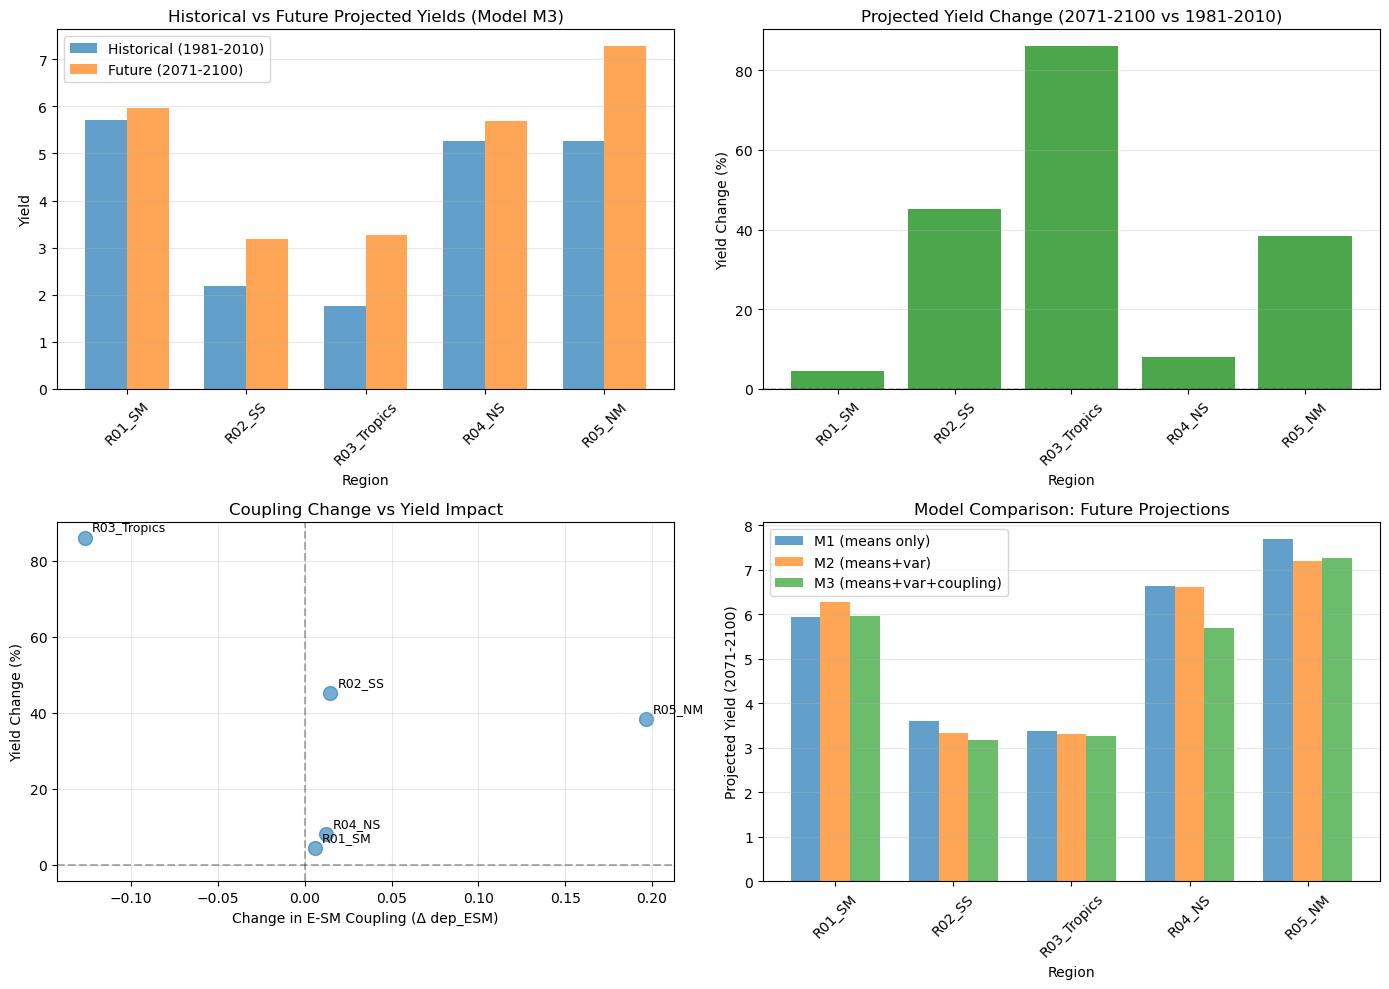

In [10]:
# =====================================================================
# STEP 5: COMPARE M1, M2, M3 PROJECTIONS
# =====================================================================

print("\n" + "="*60)
print("STEP 5: Model comparison for future projections")
print("="*60)

# How much do the models disagree?
df_future['diff_M2_M3'] = df_future['yield_M2'] - df_future['yield_M3']
df_future['diff_M1_M3'] = df_future['yield_M1'] - df_future['yield_M3']
df_future['diff_M1_M2'] = df_future['yield_M1'] - df_future['yield_M2']

model_comparison = df_future.groupby('region').agg({
    'yield_M1': 'mean',
    'yield_M2': 'mean',
    'yield_M3': 'mean',
    'diff_M1_M2': 'mean',
    'diff_M2_M3': 'mean',
    'diff_M1_M3': 'mean'
}).round(3)

print("\n=== Average projected yields by model (2071-2100) ===")
print(model_comparison)

print("\n=== Key insights ===")
print(f"Overall mean difference M2-M3: {df_future['diff_M2_M3'].mean():.3f}")
print(f"  → This shows the bias from ignoring E-SM coupling")
print(f"Overall mean difference M1-M2: {df_future['diff_M1_M2'].mean():.3f}")
print(f"  → This shows the bias from ignoring climate variability")

# =====================================================================
# STEP 6: VISUALIZE RESULTS
# =====================================================================

print("\n" + "="*60)
print("STEP 6: Creating visualizations")
print("="*60)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Historical vs Future yields
ax = axes[0, 0]
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison['yield_hist'], width, label='Historical (1981-2010)', alpha=0.7)
ax.bar(x + width/2, comparison['yield_M3_fut'], width, label='Future (2071-2100)', alpha=0.7)
ax.set_xlabel('Region')
ax.set_ylabel('Yield')
ax.set_title('Historical vs Future Projected Yields (Model M3)')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Yield change by region
ax = axes[0, 1]
colors = ['red' if x < 0 else 'green' for x in comparison['pct_change_M3']]
ax.bar(comparison.index, comparison['pct_change_M3'], color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Region')
ax.set_ylabel('Yield Change (%)')
ax.set_title('Projected Yield Change (2071-2100 vs 1981-2010)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Coupling change vs yield change
ax = axes[1, 0]
ax.scatter(comparison['delta_dep'], comparison['pct_change_M3'], s=100, alpha=0.6)
for idx, region in enumerate(comparison.index):
    ax.annotate(region, (comparison['delta_dep'].iloc[idx], 
                         comparison['pct_change_M3'].iloc[idx]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Change in E-SM Coupling (Δ dep_ESM)')
ax.set_ylabel('Yield Change (%)')
ax.set_title('Coupling Change vs Yield Impact')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3)

# Plot 4: Model comparison (M1, M2, M3)
ax = axes[1, 1]
regions = model_comparison.index
x = np.arange(len(regions))
width = 0.25
ax.bar(x - width, model_comparison['yield_M1'], width, label='M1 (means only)', alpha=0.7)
ax.bar(x, model_comparison['yield_M2'], width, label='M2 (means+var)', alpha=0.7)
ax.bar(x + width, model_comparison['yield_M3'], width, label='M3 (means+var+coupling)', alpha=0.7)
ax.set_xlabel('Region')
ax.set_ylabel('Projected Yield (2071-2100)')
ax.set_title('Model Comparison: Future Projections')
ax.set_xticks(x)
ax.set_xticklabels(regions, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('climate_yield_projections.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved: climate_yield_projections.png")

# =====================================================================
# SAVE RESULTS
# =====================================================================

df_future.to_csv('future_yield_projections.csv', index=False)
comparison.to_csv('historical_vs_future_summary.csv')
df_annual.to_csv('historical_data_with_yields.csv', index=False)

print("\n" + "="*60)
print("FILES SAVED")
print("="*60)
print("✓ future_yield_projections.csv")
print("✓ historical_vs_future_summary.csv")
print("✓ historical_data_with_yields.csv")
print("✓ climate_yield_projections.png")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)